# Data Selection and EDA

## Step 1:
The first step is coming up with an idea – arguably one of the hardest steps! Identify an original business problem for your project that can be solved with an appropriate model. By a business problem, it is meant that you should work on a problem where there is a good reason to solve it. There should be some organization or company that would find the solution to the problem useful. There are lots of ideas available online through Kaggle and other sources, but your idea should have a unique spin on it. 

- **Project Idea: Predicting Risk Levels Based on Maternal Health Attributes**

## Step 2:
The second step is locating your data. This can come from a variety of sources, e.g., Kaggle, your job, a website, API, etc. Feel free to reach out to your instructor if you are not sure if your idea and data are suitable. You may need to adjust your idea on the availability of data.

- **Data Selection: https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data**

### Variables:
1. Age: age in years when women is pregnant
2. SystolicBP: upper valjuje of blood pressure in mmHg
3. DiastolicBP: lower_value of blood pressure in mmHg
4. BS: blood glucose levels in terms of molar concentration, mmol/L
5. HeartRate: normal resting heart rate in beats per minute
6. Risk Level: Predicted risk intensity level during pregnancy

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#ignore future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Dataset

In [2]:
# Load the dataset
maternal_df = pd.read_csv('Maternal Health Risk Data Set.csv')

# Display the first few rows fo the dataset
print("Dataset Preview:")
print(maternal_df.head())

Dataset Preview:
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [3]:
# Examine data type
maternal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [4]:
# Check for missing values
print("\nMissing Values:")
print(maternal_df.isnull().sum())


Missing Values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [5]:
# Check for duplicates
duplicates = maternal_df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nDuplicate rows detected. Consider addressing them during data cleaning.")


Number of duplicate rows: 562

Duplicate rows detected. Consider addressing them during data cleaning.


In [6]:
# Remove Duplicates
maternal_df = maternal_df.drop_duplicates()

In [7]:
# Check for duplicate rows after removal
duplicates = maternal_df.duplicated().sum()
print(f"\nNumber of duplicate rows after removal: {duplicates}")


Number of duplicate rows after removal: 0


In [8]:
# Provide descriptive statistics of the dataset
print("\nDescriptive Statistics:")
print(maternal_df.describe())


Descriptive Statistics:
              Age  SystolicBP  DiastolicBP          BS    BodyTemp   HeartRate
count  452.000000  452.000000   452.000000  452.000000  452.000000  452.000000
mean    29.194690  110.553097    75.418142    8.346173   98.692478   73.949115
std     13.767379   17.872282    13.754578    2.829209    1.410897    8.156973
min     10.000000   70.000000    49.000000    6.000000   98.000000    7.000000
25%     19.000000   90.000000    65.000000    6.900000   98.000000   70.000000
50%     25.000000  120.000000    80.000000    7.500000   98.000000   76.000000
75%     35.000000  120.000000    86.000000    7.900000   98.000000   80.000000
max     70.000000  160.000000   100.000000   19.000000  103.000000   90.000000


By analyzing the descriptive analytics, there appears to be an error in the dataset, due to the minimum value of heart rate being 7 bpm. Value is replaced with the mode of the heart rate column.  

In [9]:
# find mode of of heart rate
maternal_df.HeartRate.mode()

0    70
Name: HeartRate, dtype: int64

In [10]:
# replace 7 values with 70
maternal_df.loc[maternal_df.HeartRate == 7, "HeartRate"] = 70

In [11]:
# Analyze descriptive analytics after replacing 
print("\nDescriptive Statistics:")
print(maternal_df.describe())


Descriptive Statistics:
              Age  SystolicBP  DiastolicBP          BS    BodyTemp   HeartRate
count  452.000000  452.000000   452.000000  452.000000  452.000000  452.000000
mean    29.194690  110.553097    75.418142    8.346173   98.692478   74.088496
std     13.767379   17.872282    13.754578    2.829209    1.410897    7.524161
min     10.000000   70.000000    49.000000    6.000000   98.000000   60.000000
25%     19.000000   90.000000    65.000000    6.900000   98.000000   70.000000
50%     25.000000  120.000000    80.000000    7.500000   98.000000   76.000000
75%     35.000000  120.000000    86.000000    7.900000   98.000000   80.000000
max     70.000000  160.000000   100.000000   19.000000  103.000000   90.000000


## Idea Description

Begin Milestone 1 with a 250-500-word narrative describing your original idea for the analysis/model building business problem. Clearly identify the problem you will address and the target for your model. 

### Problem Description and Target for Model

Maternal health during pregnancy is critical to ensuring positive outcomes for both the mother and baby. Many healthcare organizations and public health agencies strive to reduce adverse pregnancy outcomes, but challenges remain in identifying at-risk pregnancies early enough to enable effective intervention. Insurance companies also have a vested interest in predicting high-risk pregnancies to better manage the associated costs.

This project focuses on predicting maternal health risk levels, categorized into three categories: high risk (2), mid risk (1), and low risk (0). The primary goal is to develop a predictive model that classifies maternal health risks based on factors such as age, blood pressure, blood glucose levels, and heart rates. These indicators are routinely monitored during pregnancy to detect conditions such as hypertension, preeclampsia, gestational diabetes, and cardiovascular complications.

By analyzing the target variable, maternal health risk level, this project aims to identify which mothers are most at risk and understand the underlying reasons. This analysis will facilitate better clinical decision-making. The key question guiding this project is: How do age, blood pressure, blood glucose levels, and heart rates correlate with maternal health risk levels?

The aim of this analysis is to deepen our understanding of the relationships between these health indicators and maternal risk. This knowledge will provide actionable insights for healthcare organizations, public health agencies, and insurance companies, enabling them to optimize resource allocation, enhance preventive care measures, and reduce the incidence of adverse out comes during pregnancy.

### Target Variable

In [12]:
# Find unique values in Risk column
maternal_df.RiskLevel.unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [13]:
# Replace high risk values as 2, mid risk values as 1, and low risk as 0 for model
maternal_df.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)
# Check dataset
maternal_df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [14]:
# Adjust datatype of RiskLevel to integer
try:
    maternal_df['RiskLevel'] = maternal_df['RiskLevel'].astype(int)
    print("Conversion successful!")
    print(maternal_df.info())
    print(maternal_df)
except ValueError as e:
    print("Error in conversion:", e)

Conversion successful!
<class 'pandas.core.frame.DataFrame'>
Index: 452 entries, 0 to 705
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          452 non-null    int64  
 1   SystolicBP   452 non-null    int64  
 2   DiastolicBP  452 non-null    int64  
 3   BS           452 non-null    float64
 4   BodyTemp     452 non-null    float64
 5   HeartRate    452 non-null    int64  
 6   RiskLevel    452 non-null    int32  
dtypes: float64(2), int32(1), int64(4)
memory usage: 26.5 KB
None
     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0     25         130           80  15.0      98.0         86          2
1     35         140           90  13.0      98.0         70          2
2     29          90           70   8.0     100.0         80          2
3     30         140           85   7.0      98.0         70          2
4     35         120           60   6.1      98.0         76          0
..

The target of the model will be the intensity of risk during pregnancy based on variables such as age, blood pressure, blood glucose levels, and heart rates.  

## Graphical Analysis: 
Then, do a graphical analysis creating a minimum of four graphs. Label your graphs appropriately and explain/analyze the information provided by each graph. Your analysis should begin to answer the question(s) you are addressing. 

### Graph 1: Histogram of Age
Provide insight into common age groups with increased health risks and identify potential outliers

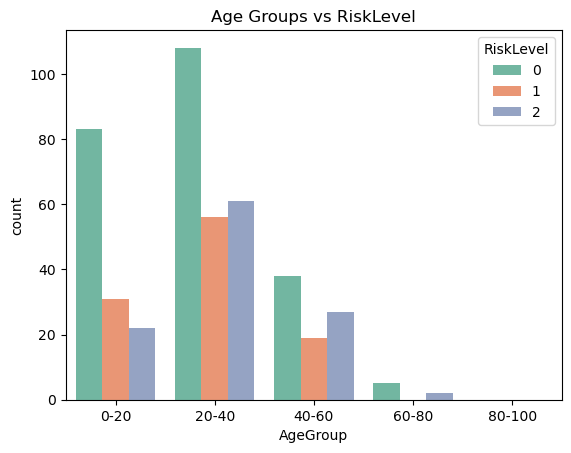

In [15]:
# Clustered Bar Chart: Age Groups vs RiskLevel
maternal_df['AgeGroup'] = pd.cut(maternal_df['Age'], bins=[0, 20, 40, 60, 80, 100], labels=['0-20', '20-40', '40-60', '60-80', '80-100'])
sns.countplot(x='AgeGroup', hue='RiskLevel', data=maternal_df, palette='Set2')
plt.title('Age Groups vs RiskLevel')
plt.show()

### Graph 2: Risk Level Bar Chart Distribution
Identify the risk level distriubtion of the data set

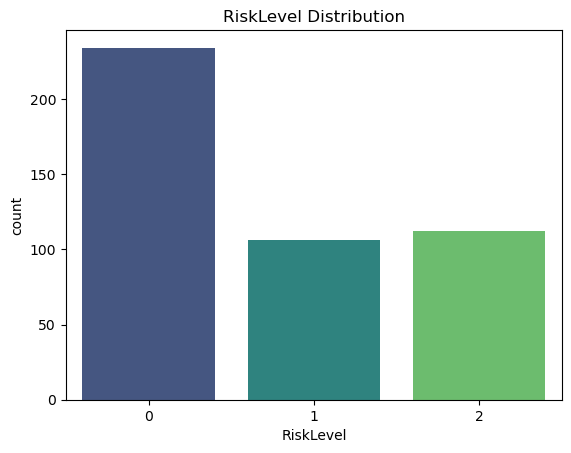

In [16]:
# Bar Chart for RiskLevel
sns.countplot(x='RiskLevel', data=maternal_df, palette='viridis')
plt.title('RiskLevel Distribution')
plt.show()

### Graph 3: Boxplots of Variables of Interest and Risk Levels
Analyze distribution of variables and search for the presence of outliers across different categories.

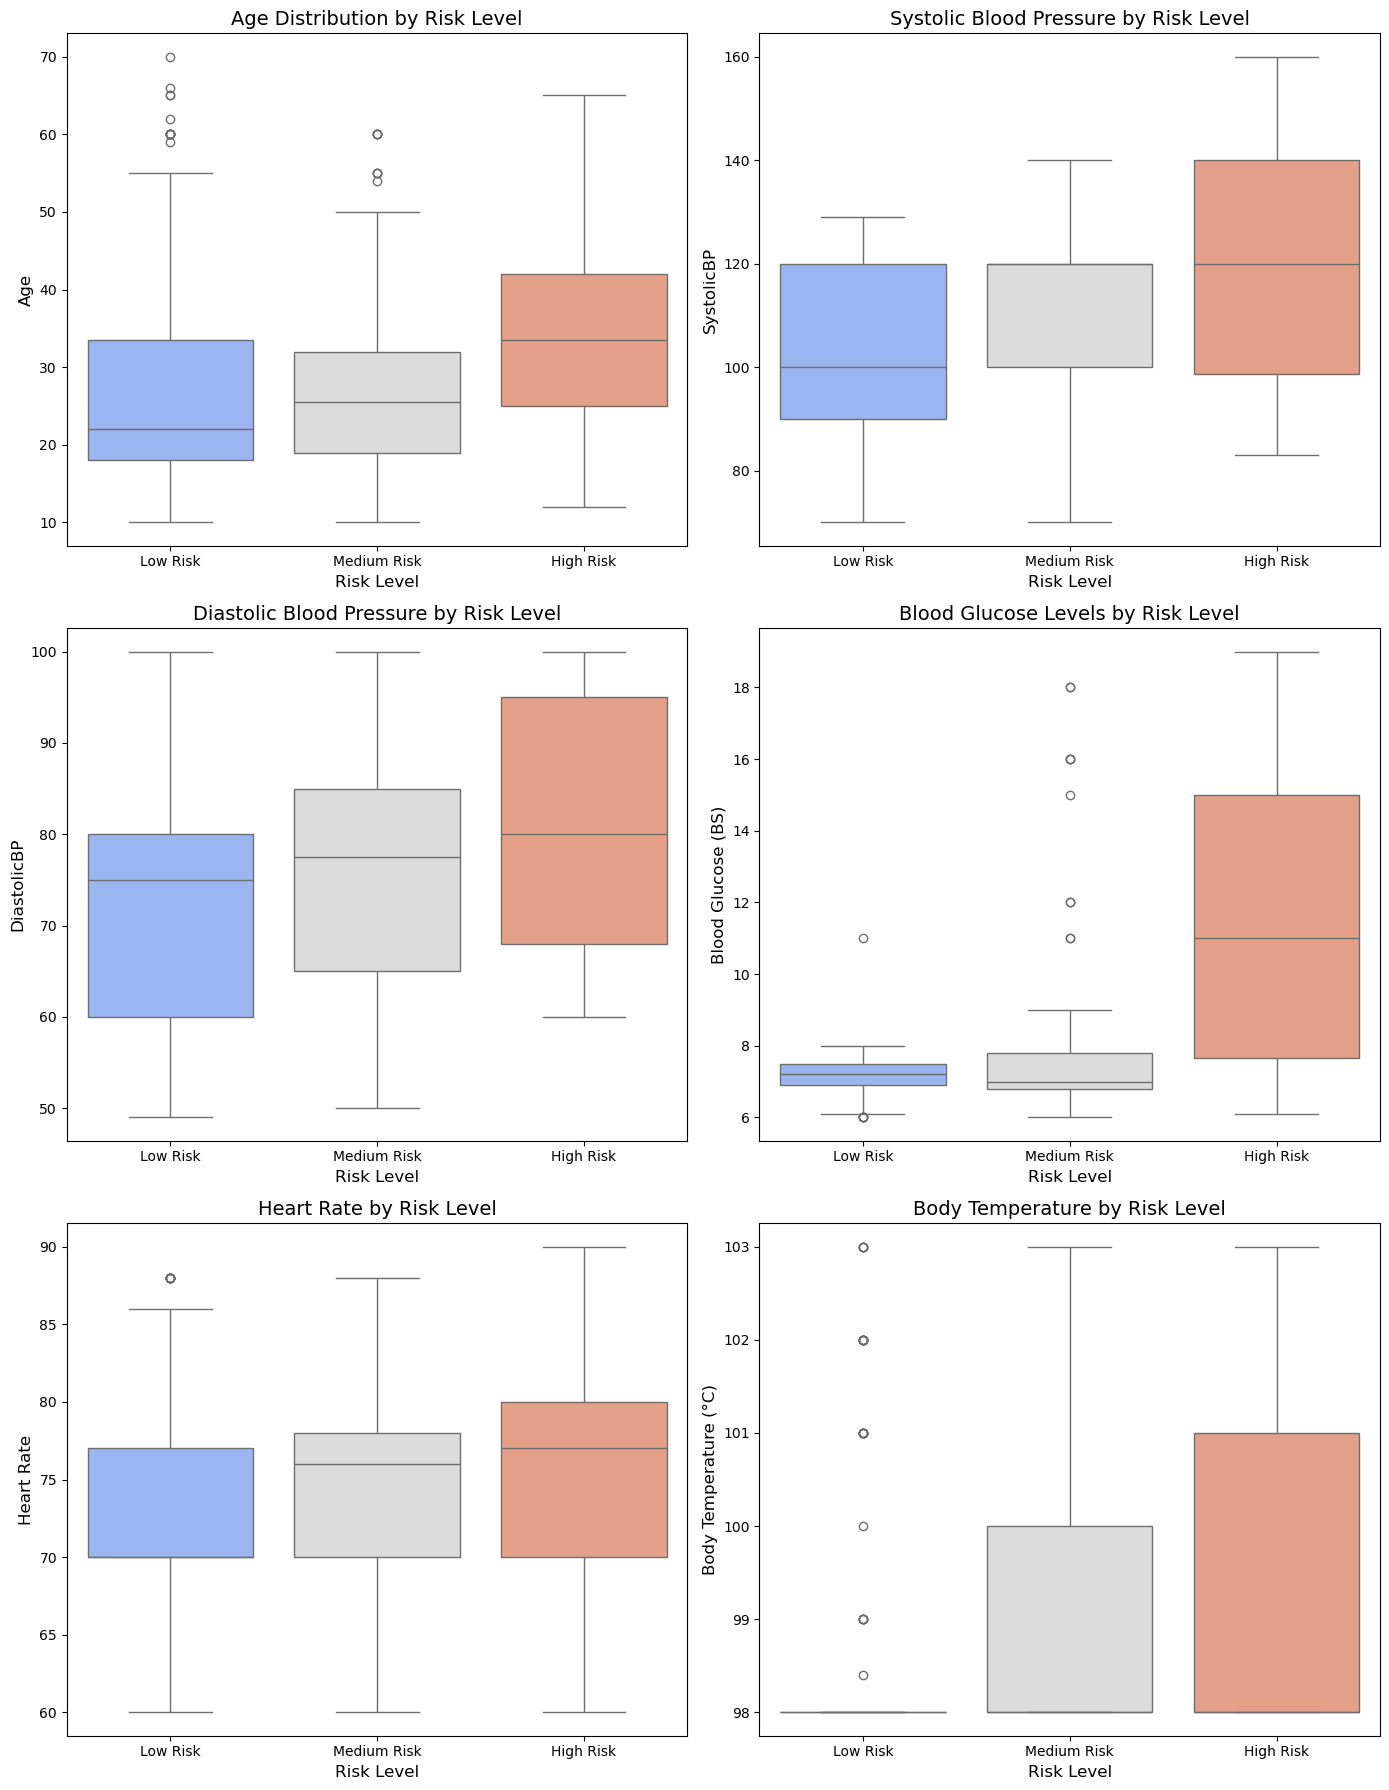

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))  # Adjusted grid to accommodate all plots

# Age Distribution
sns.boxplot(data=maternal_df, x="RiskLevel", y="Age", palette="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution by Risk Level", fontsize=14)
axes[0, 0].set_xlabel("Risk Level", fontsize=12)
axes[0, 0].set_ylabel("Age", fontsize=12)
axes[0, 0].set_xticks([0, 1, 2])
axes[0, 0].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

# Systolic Blood Pressure
sns.boxplot(data=maternal_df, x="RiskLevel", y="SystolicBP", palette="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Systolic Blood Pressure by Risk Level", fontsize=14)
axes[0, 1].set_xlabel("Risk Level", fontsize=12)
axes[0, 1].set_ylabel("SystolicBP", fontsize=12)
axes[0, 1].set_xticks([0, 1, 2])
axes[0, 1].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

# Diastolic Blood Pressure
sns.boxplot(data=maternal_df, x="RiskLevel", y="DiastolicBP", palette="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Diastolic Blood Pressure by Risk Level", fontsize=14)
axes[1, 0].set_xlabel("Risk Level", fontsize=12)
axes[1, 0].set_ylabel("DiastolicBP", fontsize=12)
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

# Blood Glucose Levels
sns.boxplot(data=maternal_df, x="RiskLevel", y="BS", palette="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Blood Glucose Levels by Risk Level", fontsize=14)
axes[1, 1].set_xlabel("Risk Level", fontsize=12)
axes[1, 1].set_ylabel("Blood Glucose (BS)", fontsize=12)
axes[1, 1].set_xticks([0, 1, 2])
axes[1, 1].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

# Heart Rate
sns.boxplot(data=maternal_df, x="RiskLevel", y="HeartRate", palette="coolwarm", ax=axes[2, 0])
axes[2, 0].set_title("Heart Rate by Risk Level", fontsize=14)
axes[2, 0].set_xlabel("Risk Level", fontsize=12)
axes[2, 0].set_ylabel("Heart Rate", fontsize=12)
axes[2, 0].set_xticks([0, 1, 2])
axes[2, 0].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

# Body Temperature
sns.boxplot(data=maternal_df, x="RiskLevel", y="BodyTemp", palette="coolwarm", ax=axes[2, 1])
axes[2, 1].set_title("Body Temperature by Risk Level", fontsize=14)
axes[2, 1].set_xlabel("Risk Level", fontsize=12)
axes[2, 1].set_ylabel("Body Temperature (°C)", fontsize=12)
axes[2, 1].set_xticks([0, 1, 2])
axes[2, 1].set_xticklabels(["Low Risk", "Medium Risk", "High Risk"], fontsize=10)

plt.tight_layout()
plt.show()


### Graph 4: Heatmap for Correlation Matrix of Age, Systolic BP, DiastolicBP, BS, Body Temp, and Heart Rate

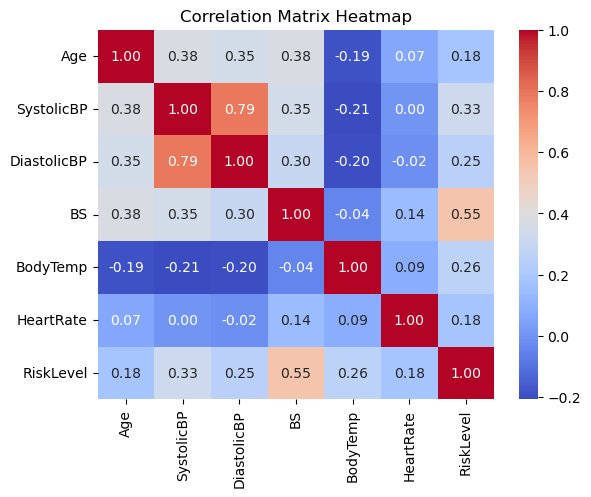

In [18]:
correlation_matrix = maternal_df[['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

## Conclusion of Insight
Write a short overview/conclusion of the insights gained from your graphical analysis.

The graphical analysis provides valuable insights into pregnancy risk levels and their associated factors. Graph 1 highlights that most pregnancies are classified as low-risk, particularly within the 20-40 age group, which also represents the largest cohort across all risk levels. It also shows a noticeable shift toward higher risk pregnancies in the 40-60 age range, which may be linked to advanced maternal age. Graph 2 reinforces this, showing that while the majority of pregnancies are low-risk, a significant portion of the population faces elevated risk, prompting further exploration of contributing factors.

Graph 3 presents boxplots illustrating key physiological factors across different pregnancy risk levels. It reveals that higher risk pregnancies are associated with older maternal age, increased blood pressure, higher blood temperatures, higher blood glucose levels, and elevated heart rates. Graph 4 explores the relationships between systolic and diastolic blood pressure, showing a strong correlation between the two, while age moderately influences blood pressure and blood sugar levels. Heart rate appears to be largely independent of the other variables. Together, these findings emphasize the need for deeper investigation into the factors that impact pregnancy risk, particularly as maternal age increases.

# Data Preparation

## Data Preparation
Now that you have created your idea, located data, and have started your graphical analysis, you will move on to the data preparation process of your project. After completing Milestone 2, your data should be ready for the model building/evaluation phase.
Here is a list of steps to consider performing in Milestone 2:
- Drop any features that are not useful for your model building and explain why they are not useful.
- Perform any data extraction/selection steps.
- Transform features if necessary.
- Engineer new useful features.
- Deal with missing data (do not just drop rows or columns without justifying this).
- Create dummy variables if necessary.
- Explain your process at each step. You can use any methods/tools you think are most appropriate. Do what makes the most sense for your data/problem. This will vary greatly among different projects. Be careful to avoid data snooping in these steps.

*Handling of missing values and encoding the categorical variable (RiskLevel) were handled during the EDA process of Milestone 1*

### Drop Feature

In [19]:
# drop less important feature (Heart Rate)
maternal_df = maternal_df.drop(columns=['HeartRate'])

After the EDA process it was discovered that heart rate had the lowest correlation and less distinction in boxplots, therefore was dropped in the data preparation process.

### Separate Target Variable

In [20]:
# Prepare dataset for model building by separating the indepent variable from the target variable

X = maternal_df.drop('RiskLevel', axis=1)
y = maternal_df['RiskLevel']

### Standardize the feature matrix X

In [21]:
# Check numerical features in the data
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp'], dtype='object')


In [22]:
# Identify problematic columns

print(X.dtypes)
print(X.select_dtypes(include=['object']).head())

Age               int64
SystolicBP        int64
DiastolicBP       int64
BS              float64
BodyTemp        float64
AgeGroup       category
dtype: object
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [23]:
# Exclude AgeGroup
X = maternal_df.drop(columns=['RiskLevel', 'AgeGroup']) 

In [24]:
# Standardize the feature matrix X using z-score normalization with StandardScaler from scikit-learn to improve model performanch
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() # create scaler object that will standardize the maternal data
scaler.fit(X) # compute mean and standard deviation of each feature in X
X_scaled = scaler.transform(X) # standardize each feature

BS, BP (Systolic and Diastolic), Age, and BodyTemp all have different scales therefore standardization was performed.

### Evaluate feature importance

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Fit a Random Forest model
model = RandomForestClassifier()
model.fit(X, y)

# Get feature importance
feature_importance = model.feature_importances_

# Create a DataFrame to view feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Sort the features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

       Feature  Importance
3           BS    0.382018
1   SystolicBP    0.198019
0          Age    0.194653
2  DiastolicBP    0.138213
4     BodyTemp    0.087097


Key Takeaway: 
The top 3 features are Blood Sugar, Age, and Systolic BP. In order to have the best model performance it may be notable to only keep the top 3, however DiastolicBP and BodyTemp may still improve accuracy slightly.

### Check for Class distribution

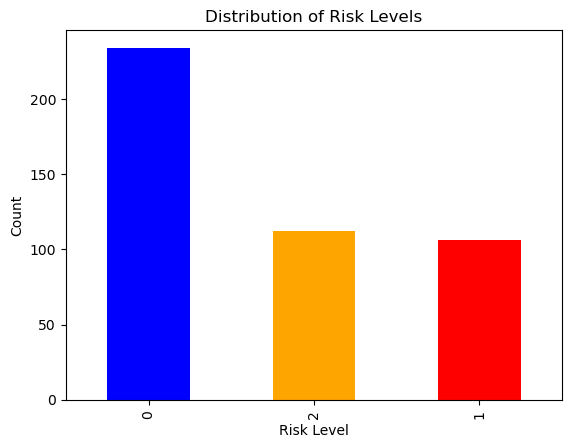

In [26]:
maternal_df['RiskLevel'].value_counts().plot(kind='bar', color=['blue', 'orange', 'red'])
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.title('Distribution of Risk Levels')
plt.show()

Since all classes are important in order to train with inbalance it is important to use stratified splitting and apply SMOTE to create synthetic samples for classes with fewer samples such as the mid risk and high risk levels. It is also important to use class weights for tree based models and SVM to adjust the model to give higher importance for minority classes.

### Split Data for Training and Testing

In [27]:
# split the datasest into training 80% and testing 20$ sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (X_scaled, y, test_size =0.2, random_state=42, stratify=y)

# Model Building and Evaluation

In Milestone 3, you will begin the process of selecting, building, and evaluating a model. You are required to train and evaluate at least one model in this milestone. Write step-by-step for performing each of these steps. You can use any methods/tools you think are most appropriate, but you should explain/justify why you are selecting the model(s) and evaluation metric(s) you choose. It is important to think about what type of model and metric makes sense for your problem. Again, do what makes the most sense for your project. Write a short overview/conclusion of the insights gained from your model building/evaluation.

**Step 1: Understand the problem and data**
- the target variable is RiskLevel with three classes 0 (low), 1 (mid), and 2 (high)
- features for prediction include: BS (blood sugar), SystolicBP and DiastolicBP, Age, and BodyTemp

Since the model is a **multi-class classification problem** possible models include:

1. Random Forest Classifier: 
2. Logistic Regression: 
3. XGBoost
4. SVM
   
Each of these models offers unique advantages for predicting RiskLevel based on the provided features (blood sugar, blood pressure (Systolic and Diastolic), age, body temperature). While Random Forest and XGBoost excel at capturing complex, non-linear relationships, Logistic Regression provides interpretability and simplicity for linear patterns. SVM is a good fit for non-linear decision boundaries and high-dimensional spaces. Together, they will offer a well-rounded toolkit for addressing the problem with a variety of strategies.

In [28]:
# import libraries to perform model building and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False)
}


Logistic Regression Performance:
Accuracy: 0.6373626373626373
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.94      0.79        47
           1       0.14      0.05      0.07        21
           2       0.68      0.57      0.62        23

    accuracy                           0.64        91
   macro avg       0.50      0.52      0.49        91
weighted avg       0.56      0.64      0.58        91



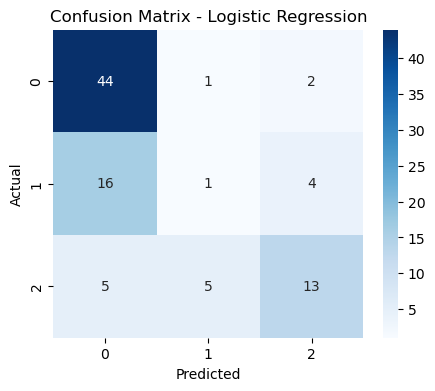


Random Forest Performance:
Accuracy: 0.7032967032967034
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.80        47
           1       0.45      0.24      0.31        21
           2       0.72      0.78      0.75        23

    accuracy                           0.70        91
   macro avg       0.64      0.63      0.62        91
weighted avg       0.67      0.70      0.68        91



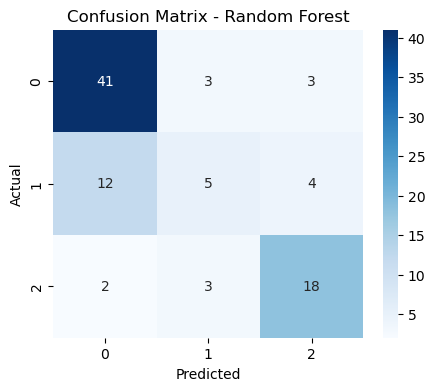


SVM Performance:
Accuracy: 0.6813186813186813
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.91      0.79        47
           1       0.00      0.00      0.00        21
           2       0.76      0.83      0.79        23

    accuracy                           0.68        91
   macro avg       0.48      0.58      0.53        91
weighted avg       0.55      0.68      0.61        91



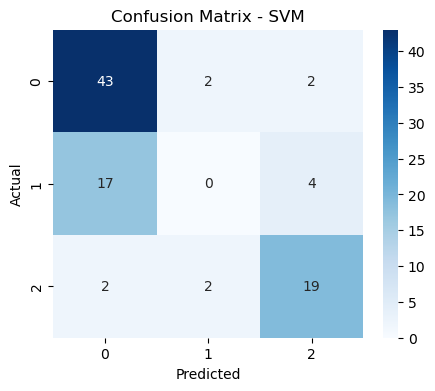

C:\Users\samue\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:17:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Performance:
Accuracy: 0.6483516483516484
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76        47
           1       0.33      0.24      0.28        21
           2       0.65      0.74      0.69        23

    accuracy                           0.65        91
   macro avg       0.58      0.59      0.58        91
weighted avg       0.62      0.65      0.63        91



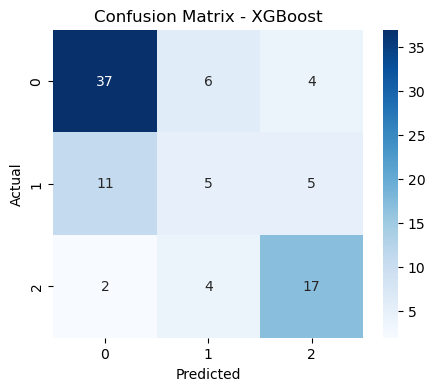

In [30]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

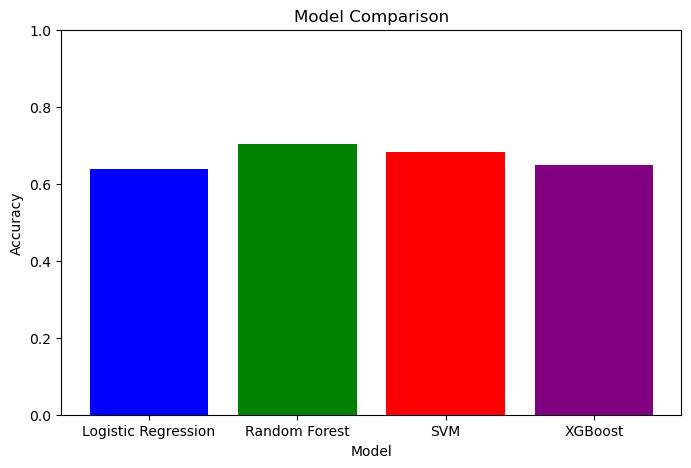

In [31]:
# Compare Model Performance
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'red', 'purple'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()

### Remove Low Importance Features and Re-train Random Forest Model using only Blood Sugar, Age, and Systolic BP.

In [32]:
# Remove low importance features and retrain Random Forest Model using only Blood Sugar, Age, and Systolic BP.

selected_features = ['BS', 'SystolicBP', 'Age']
X = maternal_df[selected_features]  
y = maternal_df['RiskLevel']  

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
# Evaluate the Model

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6483516483516484
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.89      0.78        47
           1       0.46      0.23      0.31        26
           2       0.65      0.61      0.63        18

    accuracy                           0.65        91
   macro avg       0.60      0.58      0.57        91
weighted avg       0.62      0.65      0.61        91

Confusion Matrix:
 [[42  3  2]
 [16  6  4]
 [ 3  4 11]]


## Conclusion

Logistic Regression, Random Forest, SVM, and XGBoost all achieved an accuracy above 60%. All models were not the best at predicting mid level risks. Among them, Random Forest performed the best with 70%, followed by SVM (68%), XGBoost (65%), and Logistic Regression (64%). However, when the Random Forest model was restricted to the three most important features, its accuracy dropped to 65%. This suggests that incorporating all five features yields the most optimal model. 